In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121  # or cpu version
!pip install tqdm matplotlib scikit-learn pillow

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Using device: cpu


In [4]:
LABEL_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

class BrainTumorDataset(Dataset):
    def __init__(self, dataset_path, transform=None):
        self.dataset_path = dataset_path
        self.transform = transform
        self.data = []

        for label_idx, label_name in enumerate(LABEL_NAMES):
            label_path = os.path.join(dataset_path, label_name)
            if not os.path.exists(label_path):
                print(f"Warning: {label_path} not found!")
                continue
            for filename in os.listdir(label_path):
                img_path = os.path.join(label_path, filename)
                self.data.append((img_path, label_idx))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

def load_data(dataset_path, transform=None):
    return BrainTumorDataset(dataset_path, transform=transform)

In [6]:
class TransferLearningResNet(nn.Module):
    def __init__(self, num_classes=4, dropout_rate_1=0.5, dropout_rate_2=0.5):
        super().__init__()
        self.resnet = models.resnet50(pretrained=True)
        
        # Freeze all layers
        for param in self.resnet.parameters():
            param.requires_grad = False
        # Unfreeze last block
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True

        self.resnet.fc = nn.Sequential(
            nn.Linear(self.resnet.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate_2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

def save_model(model, path="resnet_model.pth"):
    torch.save(model.state_dict(), path)
    print(f"Model saved as {path}")

In [8]:
def train_model(epochs=16, batch_size=32):
    # Transforms
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.2),
        transforms.RandomAffine(degrees=0, shear=10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    valid_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Load data
    train_dataset = load_data("data/Training", transform=train_transforms)
    valid_dataset = load_data("data/Testing", transform=valid_transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

    # Model
    model = TransferLearningResNet(num_classes=4).to(device)

    # Class weights
    train_labels = [label for _, label in train_dataset]
    class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    optimizer = torch.optim.Adam([
        {'params': model.resnet.layer4.parameters(), 'lr': 1e-5},
        {'params': model.resnet.fc.parameters(), 'lr': 1e-4}
    ], weight_decay=1e-4)

    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    # Training loop
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        print(f"Epoch {epoch+1}: Train Acc: {100*correct/total:.2f}% | Val Acc: {100*val_correct/val_total:.2f}%")

    save_model(model)
    return model

In [10]:
 model = train_model(epochs=10)

C:\Users\kouse\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\kouse\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10:  47%|████████████████████████████████▎                                    | 82/175 [04:15<04:50,  3.12s/it]


KeyboardInterrupt: 

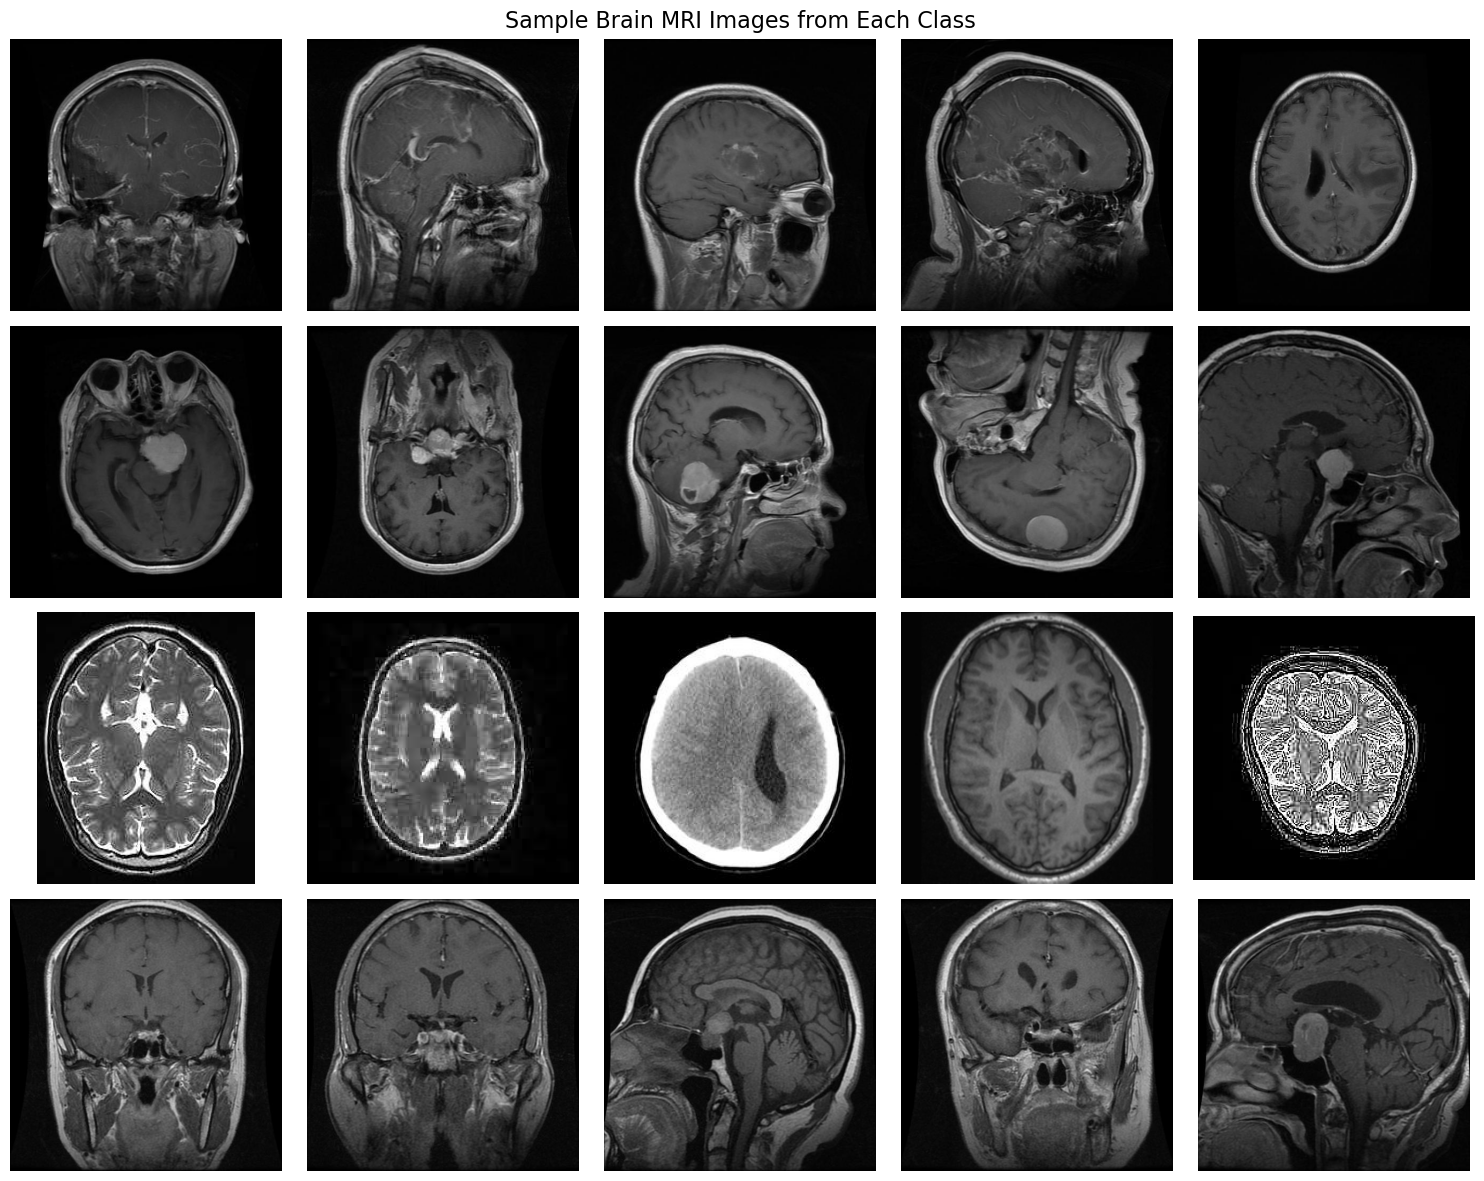

C:\Users\kouse\AppData\Local\Temp\ipykernel_3220\1232184550.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")


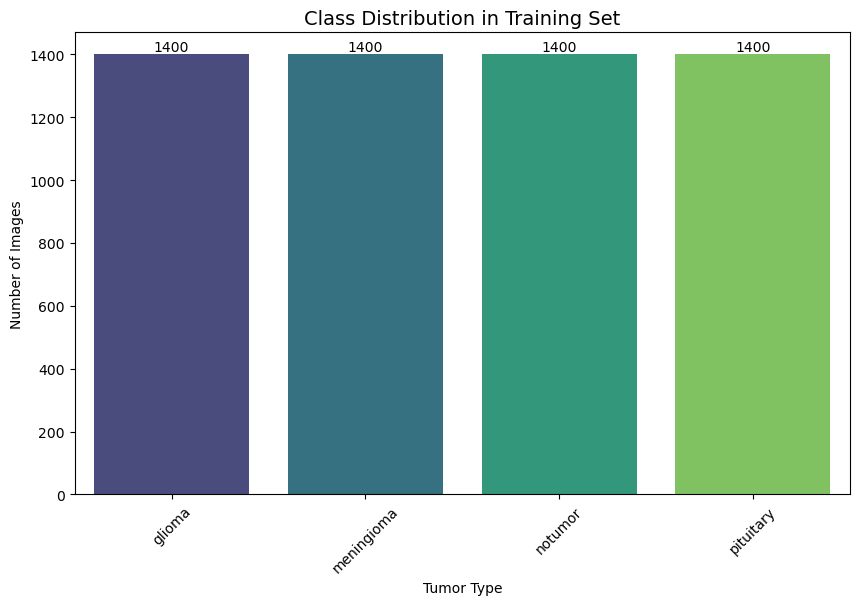

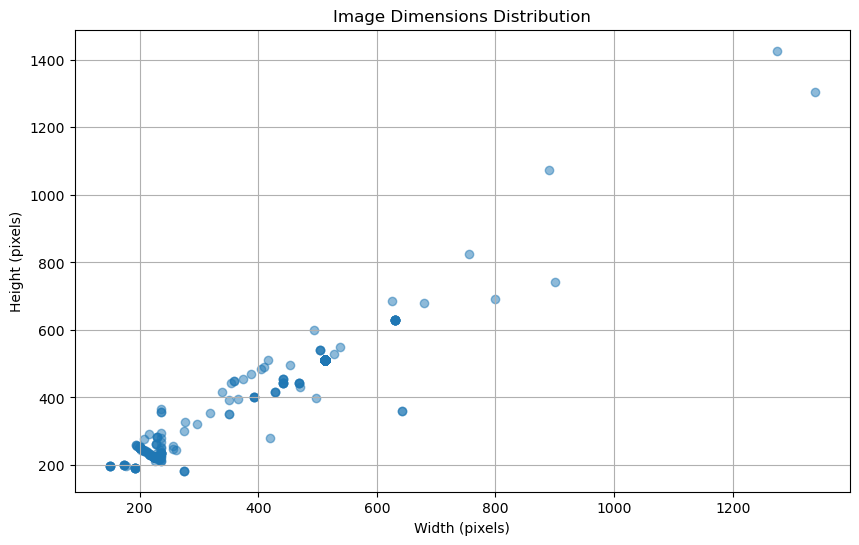

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Show sample images from each class
def show_samples(n_samples=4):
    fig, axes = plt.subplots(4, n_samples, figsize=(15, 12))
    fig.suptitle("Sample Brain MRI Images from Each Class", fontsize=16)
    
    for row, class_name in enumerate(LABEL_NAMES):
        class_path = os.path.join("data/Training", class_name)
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        for col in range(n_samples):
            if images:
                img_path = os.path.join(class_path, images[col])
                img = Image.open(img_path).convert('RGB')
                axes[row, col].imshow(img)
                axes[row, col].axis('off')
                if col == 0:
                    axes[row, col].set_ylabel(class_name, fontsize=12, rotation=0, labelpad=40)
    
    plt.tight_layout()
    plt.show()

show_samples(n_samples=5)

# 2. Class Distribution
def plot_class_distribution():
    train_path = "data/Training"
    counts = {}
    
    for class_name in LABEL_NAMES:
        path = os.path.join(train_path, class_name)
        counts[class_name] = len(os.listdir(path)) if os.path.exists(path) else 0
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")
    plt.title("Class Distribution in Training Set", fontsize=14)
    plt.xlabel("Tumor Type")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    for i, v in enumerate(counts.values()):
        plt.text(i, v + 10, str(v), ha='center')
    plt.show()

plot_class_distribution()

# 3. Image Size Distribution
def check_image_sizes():
    sizes = []
    for class_name in LABEL_NAMES:
        class_path = os.path.join("data/Training", class_name)
        for img_file in os.listdir(class_path)[:200]:  # check first 200 per class
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img = Image.open(os.path.join(class_path, img_file))
                sizes.append(img.size)
    
    widths, heights = zip(*sizes)
    plt.figure(figsize=(10, 6))
    plt.scatter(widths, heights, alpha=0.5)
    plt.title("Image Dimensions Distribution")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Height (pixels)")
    plt.grid(True)
    plt.show()

check_image_sizes()

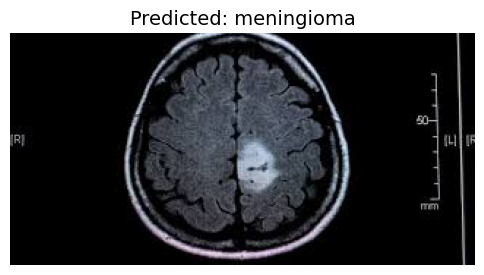

In [20]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']   # matches training labels

def load_trained_model(model_path="resnet_model.pth"):
    model = TransferLearningResNet(num_classes=4).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model

def predict_image(model, image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    image = Image.open(image_path).convert('RGB')
    img_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = output.max(1)
    
    return class_names[predicted.item()]

# Predict all images in data/New/
model = load_trained_model()

new_folder = "data/New"
for img_file in os.listdir(new_folder):
    if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
        path = os.path.join(new_folder, img_file)
        pred = predict_image(model, path)
        
        # Show result
        img = Image.open(path)
        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.title(f"Predicted: {pred}", fontsize=14)
        plt.axis('off')
        plt.show()